# CSIT 598 - Assignment 1
## 04. SVM (Linear vs RBF)

Implementation of SVM with linear and RBF kernels and their performance comparision.

In [6]:
from pathlib import Path
import json
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC

from utils import evaluate_classifier, plot_confusion, RANDOM_STATE

In [7]:
project_root = Path.cwd().parent
artifact_path = project_root / 'results' / 'metrics' / 'mnist_splits.npz'

if not artifact_path.exists():
    raise FileNotFoundError(
        f"Missing artifact: {artifact_path}. Run 01_data_preprocessing.ipynb first."
    )

data = dict(np.load(artifact_path))
X_train_std, y_train = data['X_train_std'], data['y_train']
X_val_std, y_val = data['X_val_std'], data['y_val']
X_test_std, y_test = data['X_test_std'], data['y_test']

# Use train+val for final fitting, keep test untouched
X_trainval_std = np.vstack([X_train_std, X_val_std])
y_trainval = np.concatenate([y_train, y_val])

print('Loaded standardized data:')
print(f'X_train: {X_train_std.shape}, X_val: {X_val_std.shape}, X_test: {X_test_std.shape}')

# For costly SVM tuning, use a stratified subset
X_tune, _, y_tune, _ = train_test_split(
    X_trainval_std, y_trainval,
    train_size=12000,
    stratify=y_trainval,
    random_state=RANDOM_STATE,
 )
print(f'Tuning subset: {X_tune.shape}')

Loaded standardized data:
X_train: (50000, 784), X_val: (10000, 784), X_test: (10000, 784)
Tuning subset: (12000, 784)


In [8]:
# Linear-kernel SVM tuning
linear_param_grid = {
    'C': [0.1, 1.0, 10.0],
}

linear_search = GridSearchCV(
    estimator=SVC(kernel='linear', cache_size=1000),
    param_grid=linear_param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1,
 )
linear_search.fit(X_tune, y_tune)

print('Best linear SVM params:', linear_search.best_params_)
print(f"Best linear CV accuracy: {linear_search.best_score_:.4f}")

linear_model = SVC(kernel='linear', C=linear_search.best_params_['C'], cache_size=1000)
linear_metrics = evaluate_classifier(
    linear_model, X_trainval_std, y_trainval, X_test_std, y_test
)

print('\nLinear SVM Test Metrics:')
print(f"Accuracy: {linear_metrics['accuracy']:.4f}")
print(f"Precision (macro): {linear_metrics['precision_macro']:.4f}")
print(f"Recall (macro): {linear_metrics['recall_macro']:.4f}")
print(f"F1 (macro): {linear_metrics['f1_macro']:.4f}")
print(f"Train time (s): {linear_metrics['train_time_sec']:.2f}")
print(f"Pred time (s): {linear_metrics['pred_time_sec']:.2f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best linear SVM params: {'C': 0.1}
Best linear CV accuracy: 0.9115

Linear SVM Test Metrics:
Accuracy: 0.9347
Precision (macro): 0.9342
Recall (macro): 0.9337
F1 (macro): 0.9338
Train time (s): 112.92
Pred time (s): 10.22


In [9]:
# RBF-kernel SVM tuning and evaluation
rbf_param_grid = {
    'C': [1.0, 10.0],
    'gamma': ['scale', 0.01],
}

rbf_search = GridSearchCV(
    estimator=SVC(kernel='rbf', cache_size=1000),
    param_grid=rbf_param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1,
 )
rbf_search.fit(X_tune, y_tune)

print('Best RBF SVM params:', rbf_search.best_params_)
print(f"Best RBF CV accuracy: {rbf_search.best_score_:.4f}")

# Full 60k RBF fit can be very expensive; use a larger stratified subset for final train
X_rbf_train, _, y_rbf_train, _ = train_test_split(
    X_trainval_std, y_trainval,
    train_size=20000,
    stratify=y_trainval,
    random_state=RANDOM_STATE,
 )

rbf_model = SVC(
    kernel='rbf',
    C=rbf_search.best_params_['C'],
    gamma=rbf_search.best_params_['gamma'],
    cache_size=1000,
 )
rbf_metrics = evaluate_classifier(
    rbf_model, X_rbf_train, y_rbf_train, X_test_std, y_test
)

print('\nRBF SVM Test Metrics:')
print(f"Accuracy: {rbf_metrics['accuracy']:.4f}")
print(f"Precision (macro): {rbf_metrics['precision_macro']:.4f}")
print(f"Recall (macro): {rbf_metrics['recall_macro']:.4f}")
print(f"F1 (macro): {rbf_metrics['f1_macro']:.4f}")
print(f"Train time (s): {rbf_metrics['train_time_sec']:.2f}")
print(f"Pred time (s): {rbf_metrics['pred_time_sec']:.2f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best RBF SVM params: {'C': 10.0, 'gamma': 'scale'}
Best RBF CV accuracy: 0.9463

RBF SVM Test Metrics:
Accuracy: 0.9588
Precision (macro): 0.9593
Recall (macro): 0.9584
F1 (macro): 0.9587
Train time (s): 81.00
Pred time (s): 61.83


Linear classification report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       986
           1       0.95      0.99      0.97      1125
           2       0.92      0.92      0.92       999
           3       0.90      0.91      0.91      1020
           4       0.93      0.95      0.94       975
           5       0.92      0.90      0.91       902
           6       0.95      0.96      0.96       982
           7       0.95      0.94      0.95      1042
           8       0.93      0.88      0.90       975
           9       0.92      0.91      0.92       994

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000


RBF classification report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       986
           1       0.98      0.99      0.98      1125
           2      

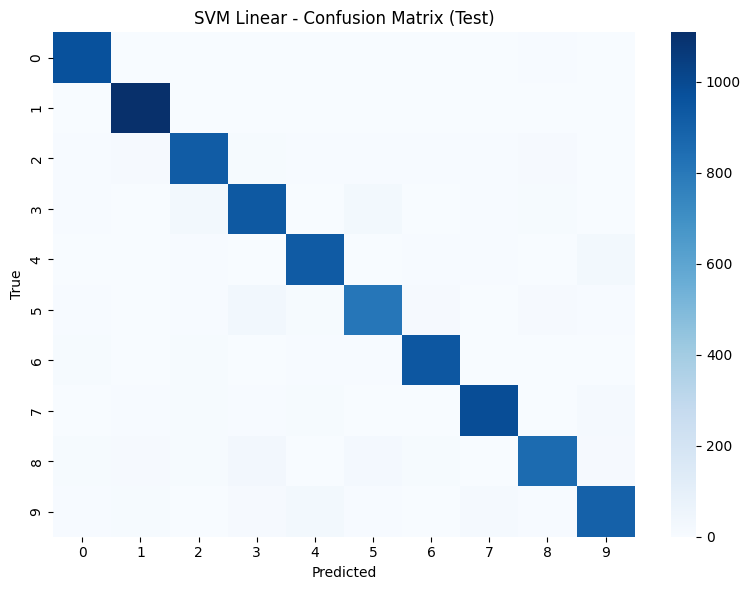

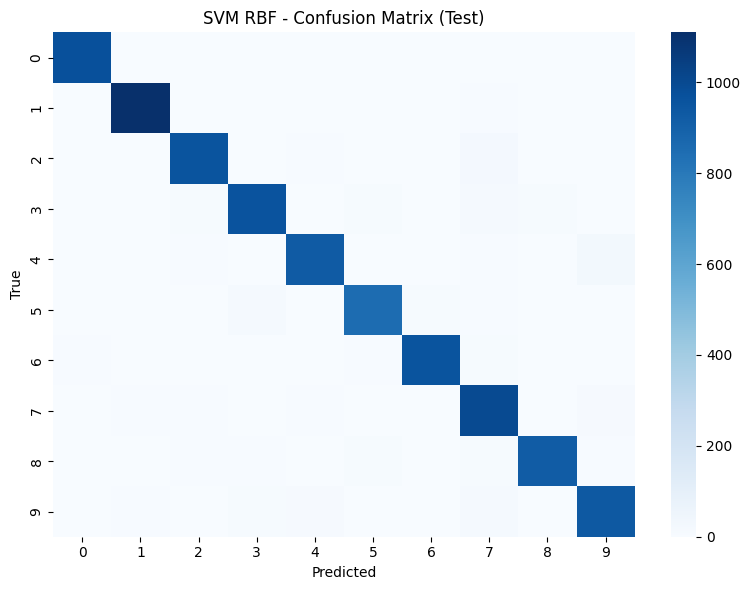


Saved:
/Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/metrics/svm_linear_metrics.json
/Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/metrics/svm_rbf_metrics.json
/Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/metrics/svm_comparison.json


In [10]:
# Save metrics and compare tradeoffs
metrics_dir = project_root / 'results' / 'metrics'
metrics_dir.mkdir(parents=True, exist_ok=True)

linear_to_save = {k: v for k, v in linear_metrics.items() if k != 'y_pred'}
linear_to_save['model_name'] = 'SVM_Linear'
linear_to_save['best_params'] = linear_search.best_params_

rbf_to_save = {k: v for k, v in rbf_metrics.items() if k != 'y_pred'}
rbf_to_save['model_name'] = 'SVM_RBF'
rbf_to_save['best_params'] = rbf_search.best_params_
rbf_to_save['train_subset_size'] = int(len(y_rbf_train))

with open(metrics_dir / 'svm_linear_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(linear_to_save, f, indent=2)

with open(metrics_dir / 'svm_rbf_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(rbf_to_save, f, indent=2)

svm_comparison = {
    'linear_accuracy': linear_metrics['accuracy'],
    'rbf_accuracy': rbf_metrics['accuracy'],
    'accuracy_delta_rbf_minus_linear': rbf_metrics['accuracy'] - linear_metrics['accuracy'],
    'linear_train_time_sec': linear_metrics['train_time_sec'],
    'rbf_train_time_sec': rbf_metrics['train_time_sec'],
}
with open(metrics_dir / 'svm_comparison.json', 'w', encoding='utf-8') as f:
    json.dump(svm_comparison, f, indent=2)

print('Linear classification report:\n')
print(linear_metrics['classification_report'])
print('\nRBF classification report:\n')
print(rbf_metrics['classification_report'])

print('\nTradeoff summary:')
print(f"Accuracy delta (RBF - Linear): {svm_comparison['accuracy_delta_rbf_minus_linear']:.4f}")
print(f"Linear train time (s): {svm_comparison['linear_train_time_sec']:.2f}")
print(f"RBF train time (s): {svm_comparison['rbf_train_time_sec']:.2f}")

plot_confusion(y_test, linear_metrics['y_pred'], title='SVM Linear - Confusion Matrix (Test)')
plot_confusion(y_test, rbf_metrics['y_pred'], title='SVM RBF - Confusion Matrix (Test)')

print('\nSaved:')
print(metrics_dir / 'svm_linear_metrics.json')
print(metrics_dir / 'svm_rbf_metrics.json')
print(metrics_dir / 'svm_comparison.json')